# Combined Jupyter feature report

This notebook intentionally combines several Jupyter-specific
features in one larger workflow: magics, shell commands, generated
files, captured shell output, widgets, rich display, timing, and
plots.


In [31]:
get_ipython().run_line_magic("matplotlib", "inline")


In [32]:
%cd .


c:\Users\dbran\OneDrive\FH\4. Semester\KIS\Jupyter2Marimo\tests\test_notebooks


## Imports and report configuration

The next cell defines reusable report settings and imports the
libraries used throughout the notebook.


In [33]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML

report_title = "Synthetic Operations Report"
filename = "report_data.csv"
notes_file = "report_notes.txt"
categories = ["alpha", "beta", "gamma", "delta"]
regions = ["north", "south", "east", "west"]


## Generate report notes

The next cell writes a small text file with Jupyter's writefile
magic.


In [34]:
%%writefile report_notes.txt
Generated report notes
======================
This file was written from a Jupyter cell.


Writing report_notes.txt


## Create synthetic report data

The CSV file is generated inside the notebook. No external input file
is required.


In [35]:
rows = []
for index in range(120):
    category = categories[index % len(categories)]
    region = regions[index % len(regions)]
    value = 20 + (index * 9) % 75
    cost = 8 + (index * 4) % 35
    rows.append({
        "id": index + 1,
        "category": category,
        "region": region,
        "value": value,
        "cost": cost,
    })

raw_data = pd.DataFrame(rows)
raw_data["profit"] = raw_data["value"] - raw_data["cost"]
raw_data.to_csv(filename, index=False)
display(raw_data.head())


,id,category,region,value,cost,profit
0,1,alpha,north,20,8,12
1,2,beta,south,29,12,17
2,3,gamma,east,38,16,22
3,4,delta,west,47,20,27
4,5,alpha,north,56,24,32


## Inspect generated files with shell commands

These cells intentionally use Jupyter shell syntax and captured shell
output.


In [36]:
!ls


Der Befehl "ls" ist entweder falsch geschrieben oder
konnte nicht gefunden werden.


In [37]:
!cat {filename}


Der Befehl "cat" ist entweder falsch geschrieben oder
konnte nicht gefunden werden.


In [38]:
files = !ls *.csv
print("csv files:", files)


csv files: ['Der Befehl "ls" ist entweder falsch geschrieben oder', 'konnte nicht gefunden werden.']


## Read files back into Python

The generated CSV and text note are loaded again for the report.


In [39]:
data = pd.read_csv(filename)
notes = Path(notes_file).read_text(encoding="utf-8")
print(notes)
display(data.head(10))


Generated report notes
This file was written from a Jupyter cell.



,id,category,region,value,cost,profit
0,1,alpha,north,20,8,12
1,2,beta,south,29,12,17
2,3,gamma,east,38,16,22
3,4,delta,west,47,20,27
4,5,alpha,north,56,24,32
5,6,beta,south,65,28,37
6,7,gamma,east,74,32,42
7,8,delta,west,83,36,47
8,9,alpha,north,92,40,52
9,10,beta,south,26,9,17


## Interactive filters

These widgets control which rows are included in the summary.


In [40]:
region_widget = widgets.Dropdown(
    options=["all"] + sorted(data["region"].unique()),
    value="all",
    description="Region:",
)
min_profit_widget = widgets.IntSlider(
    value=10,
    min=0,
    max=80,
    step=5,
    description="Min profit:",
)

display(region_widget)
display(min_profit_widget)


Dropdown(description='Region:', options=('all', 'east', 'north', 'south', 'west'), value='all')

IntSlider(value=10, description='Min profit:', max=80, step=5)

## Filter and summarize data

The filtered result depends on both widget values.


In [41]:
filtered = data[data["profit"] >= min_profit_widget.value]
if region_widget.value != "all":
    filtered = filtered[filtered["region"] == region_widget.value]

summary = filtered.groupby("category")[["value", "cost", "profit"]].mean()
display(summary)


,value,cost,profit
category,,,
alpha,65.521739,23.304348,42.217391
beta,64.700000,20.450000,44.250000
delta,62.600000,22.600000,40.000000
gamma,65.750000,18.750000,47.000000


In [42]:
%timeit data["value"].sum()


15.5 μs ± 2.85 μs per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


## Timed report calculation

This cell uses a cell magic around a small aggregate calculation.


In [43]:
%%time
total_value = filtered["value"].sum()
total_profit = filtered["profit"].sum()
print("total value:", total_value)
print("total profit:", total_profit)


total value: 5681
total profit: 3796
CPU times: total: 0 ns
Wall time: 307 μs


## Rich HTML report

The report combines values computed in earlier cells.


In [44]:
display(HTML(
    f"<h2>{report_title}</h2>"
    f"<p>Rows after filtering: <b>{len(filtered)}</b></p>"
    f"<p>Total value: <b>{total_value}</b></p>"
    f"<p>Total profit: <b>{total_profit}</b></p>"
))


## Plot results

The final charts should make the category-level differences visible.


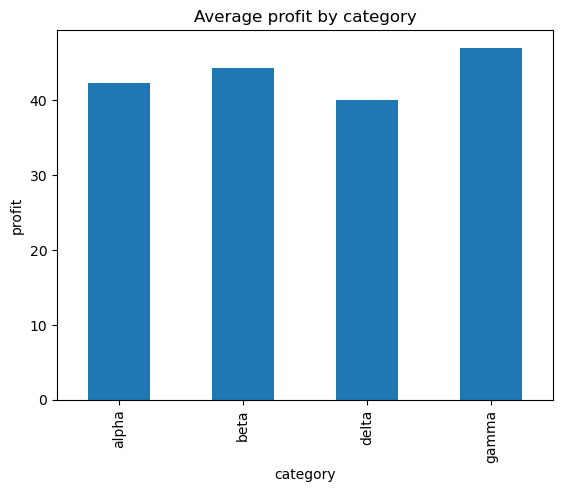

In [45]:
ax = summary["profit"].plot(kind="bar", title="Average profit by category")
ax.set_ylabel("profit")
plt.show()


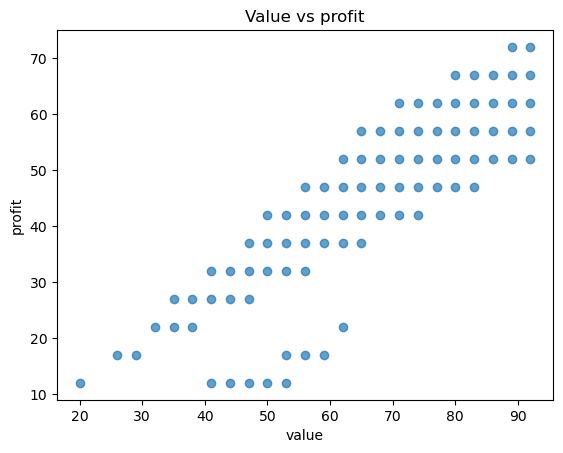

In [46]:
fig, ax = plt.subplots()
ax.scatter(filtered["value"], filtered["profit"], alpha=0.7)
ax.set_xlabel("value")
ax.set_ylabel("profit")
ax.set_title("Value vs profit")
plt.show()
